In [1]:
import numpy as np
from numpy import load
from sys import path as syspath
import os
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

from data_scripts.utils import *

base = Path.cwd()
train = load(base / '..' / 'deepwriting_dataset' / 'deepwriting_training.npz', allow_pickle=True)
test = load(base / '..' / 'deepwriting_dataset' / 'deepwriting_validation.npz', allow_pickle=True)
alphabet = train["alphabet"]

In [2]:
train.files

['subject_labels',
 'eoc_labels',
 'alphabet',
 'strokes',
 'eow_labels',
 'char_labels',
 'word_labels',
 'max',
 'min',
 'soc_labels',
 'mean',
 'texts',
 'std',
 'preprocessing',
 'sow_labels']

In [3]:
len(train["eoc_labels"])

34577

In [ ]:
def extract_character_indices(chars_to_extract, dataset):
    alphabet = list("0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ'.,-()/")
    alphabet.insert(0, chr(0))

    le = LabelEncoder()
    le.fit(alphabet)

    char_to_id = {ch: i for i, ch in enumerate(le.classes_)}
    ids_to_extract = {char_to_id[ch] for ch in chars_to_extract}

    info = {}

    for i in range(len(dataset["subject_labels"])):
        print(i)
        char_labels = dataset["char_labels"][i]
        eoc_labels = dataset["eoc_labels"][i]
        strokes = dataset["strokes"][i]

        eocs = np.nonzero(eoc_labels)[0]
        split_points = eocs + 1
        characters_split = np.split(char_labels, split_points)
        

        if len(characters_split) > 0 and len(characters_split[-1]) == 0:
            characters_split = characters_split[:-1]

        starts_and_ends = []
        start = 0
        for char_arr in characters_split:
            end = start + len(char_arr) - 1
            starts_and_ends.append([start, end])
            start = end + 1

        idx_mask = [char_arr[-1] in ids_to_extract for char_arr in characters_split]
        
        info[i] = {
            "sne": np.array(starts_and_ends, dtype=int),
            "mask": np.array(idx_mask, dtype=bool)
            }

    return info

info = extract_character_indices("e", train)

0


1
2
3


In [ ]:
len()

In [ ]:
first = train["strokes"][0]
first = offsets_to_absolute(first)

In [ ]:
first_eoc = np.asarray(np.nonzero(train["eoc_labels"][0]))[0]

In [ ]:
first_eoc

array([ 33,  52,  70, 106, 122, 136, 156, 178, 201, 220, 243, 257, 276,
       297, 325])

In [ ]:
chars = np.split(first, first_eoc)

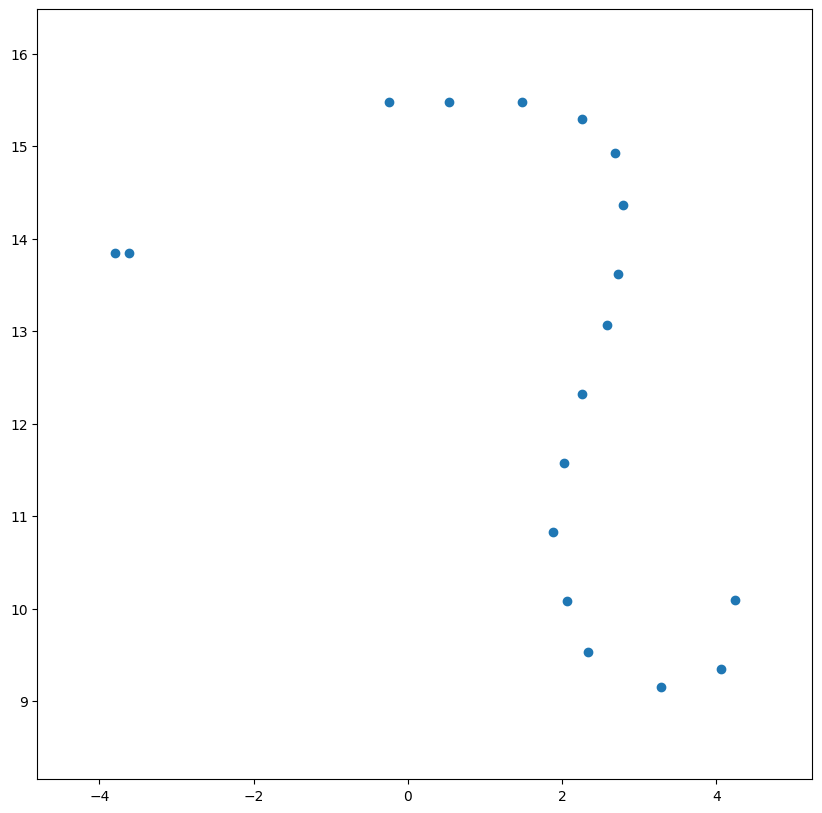

In [ ]:
char = chars[2]

x = char[:,0]
y = char[:,1]


fig, axes = plt.subplots(1,1, figsize=(10,10))


axes.set_xlim(np.min(x)-1, np.max(x)+1)
axes.set_ylim(np.min(y)-1, np.max(y)+1)

axes.scatter(x,y)